#**Pruebas t, chi cuadrada, ANOVA y Kruskal-Wallis**

En investigación médica, es fundamental comparar grupos para identificar diferencias clínicas relevantes. Para ello se utilizan distintas pruebas estadísticas, que se eligen según el tipo de variables y la distribución de los datos.
Las más utilizadas son:

*   Prueba t de Student
*   Chi-cuadrada
*   ANOVA
*   Kruskal-Wallis

In [ ]:

install.packages("tidyverse")
install.packages("janitor")
install.packages("broom")


library(tidyverse)
library(janitor)
library(broom)

datos <- read_csv("data/datos_medicos.csv") %>%
  clean_names() %>%
  mutate(
    sexo = factor(sexo),
    grupo = factor(grupo),
    fumador = factor(fumador),
    diabetes = factor(diabetes, levels = c(0, 1), labels = c("No", "Sí")),
    hipertension = factor(hipertension, levels = c(0, 1), labels = c("No", "Sí")),
    evento_complicacion = factor(evento_complicacion, levels = c(0, 1), labels = c("No", "Sí")),
    cambio_hb = hb_post - hb_pre
  )


#**1. Prueba t de Student**


**¿Para qué sirve?**
Se utiliza para comparar las medias entre dos grupos.
Ejemplos en medicina:

Comparar glucosa entre diabéticos y no diabéticos
Comparar presión arterial entre tratamiento vs control


**Tipos**

t independiente: dos grupos diferentes
t pareada: antes y después en los mismos pacientes


**Supuestos**

Variable cuantitativa (continua)
Distribución normal
Varianzas similares (homocedasticidad)
Observaciones independientes


**Interpretación**

p > 0.05 → no hay diferencia significativa
p ≤ 0.05 → hay diferencia significativa entre medias

Ejemplo:

p = 0.02 → existe diferencia significativa en la glucosa entre grupos


**Cómo se reporta**
Ejemplo:

La glucosa fue mayor en el grupo diabético (140 ± 20 mg/dL) comparado con el grupo control (110 ± 15 mg/dL), con diferencia significativa (t = 2.45, p = 0.02).


Tip
Siempre verificar normalidad antes
Si no es normal → usar Mann-Whitney

In [ ]:
library(tidyverse)
# ----------------------------------------------------------
# 1. Prueba t independiente
# Pregunta: ¿La glucosa media difiere por sexo?
# ----------------------------------------------------------


datos %>%
  group_by(sexo) %>%
  summarise(
    n = sum(!is.na(glucosa_mg_dl)),
    media = mean(glucosa_mg_dl, na.rm = TRUE),
    de = sd(glucosa_mg_dl, na.rm = TRUE)
  )

# Prueba t
t_glucosa_sexo <- t.test(glucosa_mg_dl ~ sexo, data = datos)
t_glucosa_sexo

# Resultado ordenado
resultado <- tidy(t_glucosa_sexo)
resultado

# Extraer intervalo de confianza
ic_inf <- resultado$conf.low
ic_sup <- resultado$conf.high

# Interpretación automática
cat("Diferencia de medias:", round(resultado$estimate1 - resultado$estimate2, 2), "\n")
cat("IC 95%: [", round(ic_inf, 2), ",", round(ic_sup, 2), "]\n")
cat("p valor:", round(resultado$p.value, 4), "\n")

# Interpretación simple
if(ic_inf <= 0 & ic_sup >= 0){
  cat("El intervalo incluye 0: no hay evidencia clara de diferencia entre los grupos.\n")
} else {
  cat("El intervalo NO incluye 0: hay evidencia de diferencia entre los grupos.\n")
}


# Interpretación:
# Revisar diferencia de medias, Intervalos de Confianza 95% y p valor.
# No reportar solo "significativo/no significativo"

**¿Qué es un intervalo de confianza?**

Un intervalo de confianza (IC) es un rango de valores que nos da una idea de dónde se encuentra el valor real en la población.
Por ejemplo, si calculamos la diferencia de glucosa entre hombres y mujeres, el intervalo de confianza nos dice:


 “Con un 95% de confianza, la verdadera diferencia está entre estos dos valores.”

**¿Qué significa el 95%?**
Significa que si repitiéramos el estudio muchas veces, en el 95% de los casos el intervalo incluiría el valor verdadero.

**¿Cómo se calcula (idea general)?**
Para una diferencia de medias (como en la prueba t):

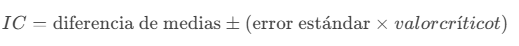


En la práctica, R lo calcula automáticamente cuando haces t.test()


**¿Cómo interpretarlo?**
Si el IC incluye el 0 → no hay evidencia clara de diferencia
Si el IC NO incluye el 0 → hay evidencia de diferencia
El intervalo también muestra qué tan grande podría ser el efecto

 Ejemplo:

IC: (-5, 2) → incluye 0 → no concluyente
IC: (1, 8) → no incluye 0 → sí hay diferencia

In [ ]:
# ----------------------------------------------------------
# 2. Prueba t pareada
# Pregunta: ¿Cambió la hemoglobina después del tratamiento?
# ----------------------------------------------------------

t_hb_pareada <- t.test(datos$hb_post, datos$hb_pre, paired = TRUE)
t_hb_pareada
tidy(t_hb_pareada)

datos %>%
  summarise(
    media_pre = mean(hb_pre, na.rm = TRUE),
    media_post = mean(hb_post, na.rm = TRUE),
    media_cambio = mean(cambio_hb, na.rm = TRUE),
    de_cambio = sd(cambio_hb, na.rm = TRUE)
  )

In [ ]:
# ----------------------------------------------------------
# 3. Alternativa no paramétrica para muestras pareadas
# ----------------------------------------------------------

wilcox.test(datos$hb_post, datos$hb_pre, paired = TRUE)


#**2. Prueba Chi-cuadrada (χ²)**
**¿Para qué sirve?**
Se utiliza para comparar variables categóricas (proporciones).
Ejemplos:

Frecuencia de diabetes en hombres vs mujeres
Complicaciones (sí/no) entre grupos


**Supuestos**

Variables categóricas
Frecuencias esperadas ≥ 5 (idealmente)
Observaciones independientes


**Interpretación**

p ≤ 0.05 → existe asociación entre variables
p > 0.05 → no hay asociación

Ejemplo:

p = 0.03 → hay asociación entre tabaquismo y enfermedad


**Cómo se reporta**
Ejemplo:

Se observó una asociación significativa entre tabaquismo y complicaciones (χ² = 6.12, p = 0.03).


**Tip**

Si hay frecuencias pequeñas → usar Fisher exacta

In [ ]:

tabla_diabetes_evento <- table(datos$diabetes, datos$evento_complicacion)
tabla_diabetes_evento

chisq.test(tabla_diabetes_evento)

# Ver esperados
chisq.test(tabla_diabetes_evento)$expected

# Si hay frecuencias esperadas pequeñas:
fisher.test(tabla_diabetes_evento)

#**3. ANOVA (Análisis de varianza)**
**¿Para qué sirve?**
Se usa para comparar medias entre ≥ 3 grupos.
Ejemplo:

Comparar colesterol entre 3 tratamientos
Comparar niveles de glucosa entre tres grupos clínicos


**Supuestos**

Variable cuantitativa continua
Distribución normal en cada grupo
Homogeneidad de varianzas
Independencia de observaciones


**Interpretación**

p ≤ 0.05 → al menos un grupo es diferente
p > 0.05 → no hay diferencias

**Importante:**
ANOVA no te dice entre qué grupos está la diferencia.
→ Se requieren pruebas post-hoc (Tukey)

**Cómo se reporta**
Ejemplo:

Se encontraron diferencias significativas en los niveles de colesterol entre los grupos (F = 4.32, p = 0.01).


**Tip**
Si p < 0.05 → hacer comparaciones múltiples
Si no hay normalidad → usar Kruskal-Wallis

In [ ]:
datos %>%
  group_by(grupo) %>%
  summarise(
    n = sum(!is.na(glucosa_mg_dl)),
    media = mean(glucosa_mg_dl, na.rm = TRUE),
    de = sd(glucosa_mg_dl, na.rm = TRUE)
  )

modelo_anova <- aov(glucosa_mg_dl ~ grupo, data = datos)
summary(modelo_anova)

# Post hoc de Tukey
TukeyHSD(modelo_anova)

# Diagnóstico básico de residuos
par(mfrow = c(1, 2))
plot(modelo_anova, which = 1)
plot(modelo_anova, which = 2)
par(mfrow = c(1, 1))

#**¿Cómo interpretar la tabla de ANOVA?**

Tienes la siguiente salida:
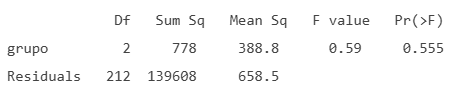

 ¿Qué significa cada columna?
Df (grados de libertad)

grupo = 2 → número de grupos - 1
Hay 3 grupos en total
residuos = 212 → variabilidad individual


Sum Sq (suma de cuadrados)

grupo (778) → variabilidad entre los grupos
residuals (139608) → variabilidad dentro de los grupos

Observación importante:

La variabilidad dentro de los grupos es mucho mayor que entre grupos → mala señal para encontrar diferencias


Mean Sq (cuadrado medio)
Se calcula como:
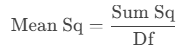

grupo: 388.8
residuos: 658.5


 F value (estadístico F)
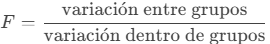
Aquí:

F = 0.59

Interpretación:

Valor cercano a 1 o menor → los grupos son muy similares
Si fuera alto → indicaría diferencias


Pr(>F) = p-valor

p = 0.555


**Interpretación estadística**
Regla:

p ≤ 0.05 → diferencias significativas
p > 0.05 → no hay diferencias

 En este caso:
 p = 0.555 > 0.05

** Conclusión
 No hay diferencias estadísticamente significativas entre los grupos
Es decir:

No existe evidencia de que la media de la variable analizada sea diferente entre los grupos.


**Interpretación clínica**

Las diferencias observadas pueden deberse al azar
Los grupos son estadísticamente similares
No se justifica hacer post-hoc (Tukey)


Cómo reportarlo en un artículo o tarea

No se encontraron diferencias significativas entre los grupos (ANOVA: F(2,212) = 0.59, p = 0.555).


 Tip

Si el ANOVA sale:

 significativo (p ≤ 0.05) → hacer Tukey
 no significativo (p > 0.05) → detenerse, no continuar


#**4. Kruskal-Wallis**
**¿Para qué sirve?**

Es la alternativa no paramétrica del ANOVA.
Se usa cuando:

Los datos NO son normales
Hay ≥ 3 grupos

Ejemplo:

Días de estancia entre 3 tratamientos
Niveles de glucosa no normales


**Supuestos**

Variable ordinal o continua
No requiere normalidad
Grupos independientes





**Interpretación**

p ≤ 0.05 → hay diferencias entre grupos
p > 0.05 → no hay diferencias


**Cómo se reporta**


Se encontraron diferencias significativas en los días de estancia entre los grupos (H = 8.45, p = 0.01).


**Tip**
Después, hacer comparaciones post-hoc (Bonferroni o Dunn)

In [ ]:
datos %>%
  group_by(grupo) %>%
  summarise(
    n = n(),
    mediana = median(dias_estancia, na.rm = TRUE),
    q1 = quantile(dias_estancia, 0.25, na.rm = TRUE),
    q3 = quantile(dias_estancia, 0.75, na.rm = TRUE)
  )

kruskal.test(dias_estancia ~ grupo, data = datos)

# Comparaciones por pares si Kruskal-Wallis es relevante
pairwise.wilcox.test(
  x = datos$dias_estancia,
  g = datos$grupo,
  p.adjust.method = "bonferroni"
)

##**Ejercicios**

**Ejercicio 1:**
Comparar colesterol_mg_dl entre pacientes con y sin diabetes.

**Ejercicio 2:**
Evaluar asociación entre hipertension y evento_complicacion.

**Ejercicio 3:**
Comparar presion_sistolica entre los tres grupos.

**Ejercicio 4:**
Comparar dias_estancia por evento_complicacion.
